In [69]:
# Install required packages
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install', 'wfdb', 'tqdm', '--quiet'])
print('Packages ready.')

Packages ready.


In [70]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.


## 1. Imports & Environment Setup

In [71]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from sklearn.preprocessing import MinMaxScaler
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)

print('All imports OK.')

All imports OK.


## 2. Paper Configuration (Section 3, Dudukcu et al. 2023)

In [72]:
# ── MIT-BIH Arrhythmia Database path ────────────────────────────────────────
# The database folder sits next to this notebook, so we resolve it relative to
# the current working directory — portable across machines / OSes (no hard-coded
# drive letters). Falls back gracefully with a clear message if it's missing.
DATA_DIR = os.path.join(os.getcwd(), "mit-bih-arrhythmia-database-1.0.0")
assert os.path.isdir(DATA_DIR), (
    f"MIT-BIH folder not found at:\n  {DATA_DIR}\n"
    f"Make sure 'mit-bih-arrhythmia-database-1.0.0' is in the same folder as this notebook."
)

# ── Exact constants from the paper (Section 3) ───────────────────────────────
FS           = 360        # sampling frequency (360 samples/second)
TOTAL_STEPS  = 100_000    # '100,000 time-step ECG data' per patient
TRAIN_STEPS  = 40_000     # '40,000 time-steps for training'
VAL_STEPS    = 10_000     # '10,000 time-steps for validation'
TEST_STEPS   = 50_000     # '50,000 time-steps as test data'

LOOKBACK     = 10         # '10-time step history windows'
HORIZON      = 1          # 'one time-step of prediction horizon'

# ── 21 patients: full MIT-BIH set MINUS patients 111 and 118 ────────────────
# Paper: 'Patient 111 and Patient 118 from 23 patients were excluded
#         ... because models could not be trained correctly'
PATIENTS = [
    '100', '101', '102', '103', '104', '105',
    '106', '107', '108', '109', '112', '113',
    '114', '115', '116', '117', '119',
    '121', '122', '123', '124'
]
assert len(PATIENTS) == 21, f'Expected 21 patients, got {len(PATIENTS)}'

print(f'Data dir         : {DATA_DIR}')
print(f'Patients         : {len(PATIENTS)}')
print(f'Sampling freq    : {FS} Hz')
print(f'Total steps/pt   : {TOTAL_STEPS:,}')
print(f'Train/Val/Test   : {TRAIN_STEPS:,} / {VAL_STEPS:,} / {TEST_STEPS:,}')
print(f'Lookback window  : {LOOKBACK} steps  →  {LOOKBACK/FS*1000:.1f} ms')
print(f'Pred horizon     : {HORIZON} step   →  {HORIZON/FS*1000:.1f} ms')
print(f'Excluded         : 111, 118 (paper: outlier values during benchmarking)')

Data dir         : /Users/ahmedkhader/My Projects/implementation/NVAR:NGCR/mit-bih-arrhythmia-database-1.0.0
Patients         : 21
Sampling freq    : 360 Hz
Total steps/pt   : 100,000
Train/Val/Test   : 40,000 / 10,000 / 50,000
Lookback window  : 10 steps  →  27.8 ms
Pred horizon     : 1 step   →  2.8 ms
Excluded         : 111, 118 (paper: outlier values during benchmarking)


## 3. Data Loading & Preprocessing

Pipeline follows Section 3 of the paper exactly:
1. Load MLII lead from MIT-BIH Arrhythmia Database using `wfdb`.
2. Truncate / pad to exactly `TOTAL_STEPS` samples.
3. Split: train (0–40k), validation (40k–50k), test (50k–100k).
4. Min-Max normalise — scaler fitted on **train only** to prevent leakage.
5. Build sliding-window sequences: X = 10 steps, y = next step (1-step-ahead).

In [73]:
def load_ecg_signal(record_id: str, data_dir: str, n_steps: int = 100_000) -> np.ndarray:
    """
    Load the MLII lead (or first available lead) from a MIT-BIH record
    and return exactly n_steps samples.

    Paper (Section 3.1): 'digitizing the two-channel ambulatory ECG recordings
    of a 24-hour period with a sampling frequency of 360 samples per second.'
    The amplitude is estimated 2 ms ahead using 28 ms history windows.
    Here we load the raw signal; history windowing is applied in make_sequences().
    """
    path = os.path.join(data_dir, record_id)
    rec  = wfdb.rdrecord(path)

    # Prefer MLII lead; fall back to first available channel
    sig_names_upper = [s.upper() for s in rec.sig_name]
    ch = sig_names_upper.index('MLII') if 'MLII' in sig_names_upper else 0

    signal = rec.p_signal[:, ch].astype(np.float32)

    # Pad with the last value if the recording is shorter than n_steps
    if len(signal) < n_steps:
        pad = np.full(n_steps - len(signal), signal[-1], dtype=np.float32)
        signal = np.concatenate([signal, pad])

    return signal[:n_steps]


def preprocess_patient(
    signal: np.ndarray,
    train_steps: int = 40_000,
    val_steps:   int = 10_000,
) -> tuple:
    """
    Split signal into train / val / test, then apply Min-Max normalisation.

    Paper (Section 3): 'For both datasets, 40,000 time-steps are separated
    for training data, 10,000 time-steps for validation data, and 50,000
    time-steps as test data.'

    Scaler is fitted on the training partition only to avoid data leakage.
    Returns: (train_norm, val_norm, test_norm, fitted_scaler)
    """
    train_end = train_steps
    val_end   = train_steps + val_steps

    train_raw = signal[:train_end]          # 0     – 39,999
    val_raw   = signal[train_end:val_end]   # 40,000 – 49,999
    test_raw  = signal[val_end:]            # 50,000 – 99,999

    scaler     = MinMaxScaler(feature_range=(0, 1))
    train_norm = scaler.fit_transform(train_raw.reshape(-1, 1)).flatten()
    val_norm   = scaler.transform(val_raw.reshape(-1, 1)).flatten()
    test_norm  = scaler.transform(test_raw.reshape(-1, 1)).flatten()

    return train_norm, val_norm, test_norm, scaler


def make_sequences(
    signal:   np.ndarray,
    lookback: int = 10,
    horizon:  int = 1,
) -> tuple:
    """
    Build sliding-window (X, y) pairs for supervised time-series prediction.

    Paper (Section 3.2): '10-time step history windows for one time-step of
    prediction horizon' and 'the amplitude of the signal was estimated 2 ms
    ahead by using input data sequences with 28 ms history window.'
    (28 ms @ 360 Hz ≈ 10 samples; 2 ms @ 360 Hz ≈ 1 sample ahead)

    X[i] = signal[i : i+lookback]   shape (lookback,)
    y[i] = signal[i + lookback]     scalar
    """
    X, y = [], []
    for i in range(len(signal) - lookback - horizon + 1):
        X.append(signal[i : i + lookback])
        y.append(signal[i + lookback])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


print('Preprocessing functions defined.')
print(f'  load_ecg_signal()   — reads MLII lead, truncates/pads to {TOTAL_STEPS:,} steps')
print(f'  preprocess_patient() — splits {TRAIN_STEPS:,}/{VAL_STEPS:,}/{TEST_STEPS:,}, MinMax-normalises')
print(f'  make_sequences()    — sliding window: X={LOOKBACK} steps → y=1 step ahead')

Preprocessing functions defined.
  load_ecg_signal()   — reads MLII lead, truncates/pads to 100,000 steps
  preprocess_patient() — splits 40,000/10,000/50,000, MinMax-normalises
  make_sequences()    — sliding window: X=10 steps → y=1 step ahead


In [74]:
# patient_data[rid] contains the preprocessed split arrays and the fitted scaler.
# Structure: {'X_train', 'y_train', 'X_val', 'y_val', 'X_test', 'y_test', 'scaler'}
patient_data = {}

print(f'Loading and preprocessing {len(PATIENTS)} patients...\n')
for rid in tqdm(PATIENTS, desc='Patients'):
    # Step 1 — load raw signal
    signal = load_ecg_signal(rid, DATA_DIR, n_steps=TOTAL_STEPS)

    # Step 2 — split + normalise
    tr, vl, te, sc = preprocess_patient(signal, TRAIN_STEPS, VAL_STEPS)

    # Step 3 — build sliding-window sequences for each partition
    X_tr, y_tr = make_sequences(tr, LOOKBACK, HORIZON)
    X_vl, y_vl = make_sequences(vl, LOOKBACK, HORIZON)
    X_te, y_te = make_sequences(te, LOOKBACK, HORIZON)

    patient_data[rid] = {
        'X_train': X_tr, 'y_train': y_tr,
        'X_val'  : X_vl, 'y_val'  : y_vl,
        'X_test' : X_te, 'y_test' : y_te,
        'scaler' : sc,
    }
    tqdm.write(
        f'  Patient {rid:>3s} | '
        f'train={X_tr.shape}  val={X_vl.shape}  test={X_te.shape}'
    )

print('\nAll patients loaded.')

Loading and preprocessing 21 patients...



Patients:   0%|          | 0/21 [00:00<?, ?it/s]

  Patient 100 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)


Patients:  10%|▉         | 2/21 [00:00<00:01, 18.20it/s]

  Patient 101 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 102 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)


...

  Patient 121 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)
  Patient 122 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)


Patients:  95%|█████████▌| 20/21 [00:01<00:00, 18.11it/s]

  Patient 123 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)


Patients: 100%|██████████| 21/21 [00:01<00:00, 18.17it/s]

  Patient 124 | train=(39990, 10)  val=(9990, 10)  test=(49990, 10)

All patients loaded.


## 4. Preprocessing Verification

Sanity-check that every patient's arrays match the shapes and value ranges
expected from the paper's description.

In [75]:
# ── Expected shapes from paper ───────────────────────────────────────────────
# train partition: 40,000 samples  → sequences: 40,000 - 10 - 1 + 1 = 39,990
# val   partition: 10,000 samples  →            10,000 - 10 - 1 + 1 =  9,990
# test  partition: 50,000 samples  →            50,000 - 10 - 1 + 1 = 49,990
EXP_TRAIN_N = TRAIN_STEPS - LOOKBACK - HORIZON + 1   # 39,990
EXP_VAL_N   = VAL_STEPS   - LOOKBACK - HORIZON + 1   #  9,990
EXP_TEST_N  = TEST_STEPS  - LOOKBACK - HORIZON + 1   # 49,990

print(f'Expected sequence counts:')
print(f'  Train : {EXP_TRAIN_N:,}')
print(f'  Val   : {EXP_VAL_N:,}')
print(f'  Test  : {EXP_TEST_N:,}\n')

all_ok = True
rows = []
for rid in PATIENTS:
    d = patient_data[rid]
    shape_ok  = (
        d['X_train'].shape == (EXP_TRAIN_N, LOOKBACK) and
        d['X_val'].shape   == (EXP_VAL_N,   LOOKBACK) and
        d['X_test'].shape  == (EXP_TEST_N,  LOOKBACK)
    )
    # After MinMax normalisation all values should be in [0, 1] for train
    scale_ok  = (
        float(d['X_train'].min()) >= -1e-6 and
        float(d['X_train'].max()) <=  1 + 1e-6
    )
    nan_ok    = not (np.isnan(d['X_train']).any() or np.isnan(d['X_test']).any())
    status    = '✅' if (shape_ok and scale_ok and nan_ok) else '❌'
    if not (shape_ok and scale_ok and nan_ok):
        all_ok = False
    rows.append({
        'Patient' : rid,
        'Train X' : str(d['X_train'].shape),
        'Val X'   : str(d['X_val'].shape),
        'Test X'  : str(d['X_test'].shape),
        'Scale OK': '✅' if scale_ok else '❌',
        'NaN free': '✅' if nan_ok  else '❌',
        'Status'  : status,
    })

df_check = pd.DataFrame(rows).set_index('Patient')
print(df_check.to_string())
print()
if all_ok:
    print('✅  All 21 patients pass shape, scale, and NaN checks.')
else:
    print('❌  One or more patients failed verification — check DATA_DIR and signal lengths.')

Expected sequence counts:
  Train : 39,990
  Val   : 9,990
  Test  : 49,990

             Train X       Val X       Test X Scale OK NaN free Status
Patient                                                               
100      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
101      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
102      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
103      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
104      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
105      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
106      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
107      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
108      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
109      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅
112      (39990, 10)  (9990, 10)  (49990, 10)        ✅        ✅      ✅


## 5. Signal Visualisation (Sanity Check)

Plot a representative segment from Patient 103 across all three partitions
to confirm the normalised signal looks physiologically plausible before training.

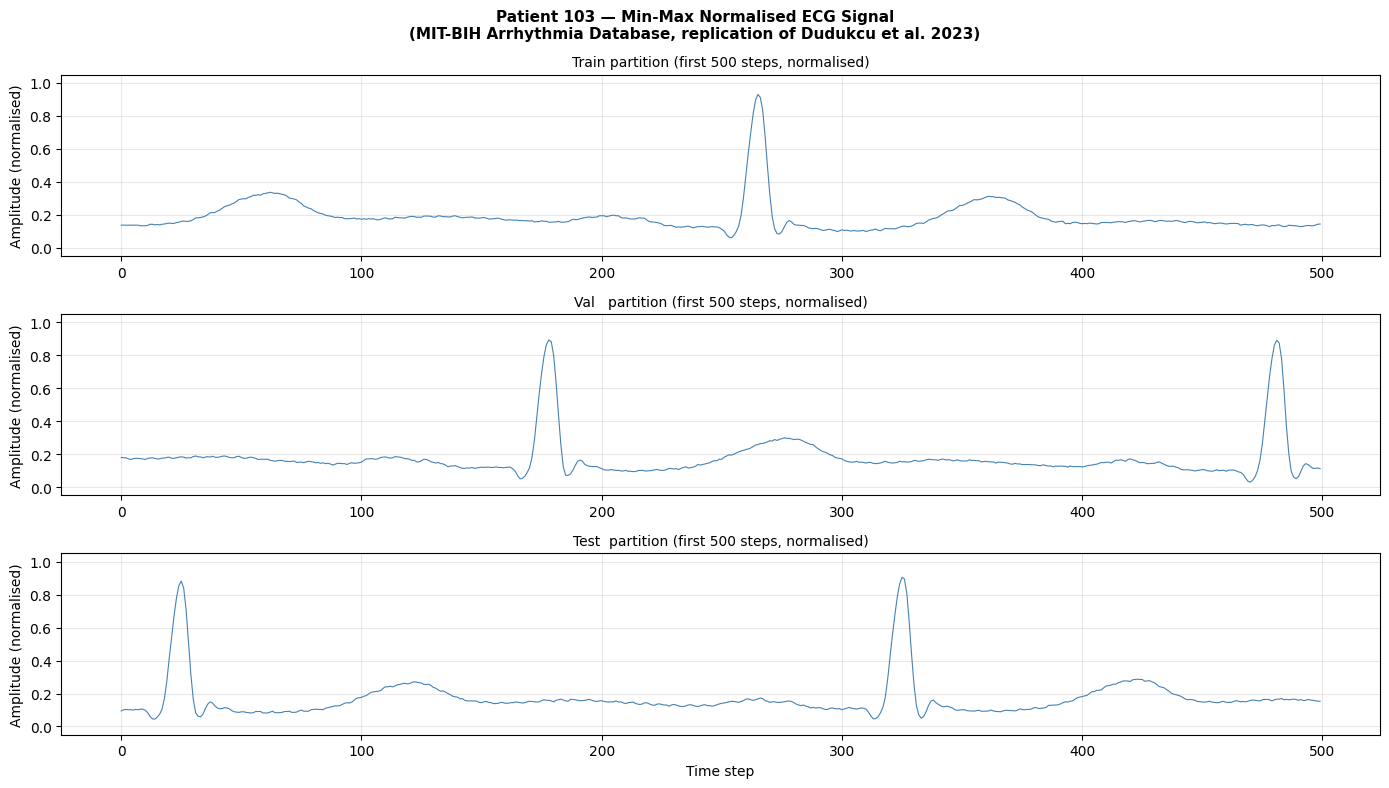

Plot saved to patient103_preprocessed.png


In [76]:
DEMO_PATIENT = '103'
d = patient_data[DEMO_PATIENT]

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=False)

segments = [
    ('Train partition (first 500 steps, normalised)', d['X_train'][:500, 0]),
    ('Val   partition (first 500 steps, normalised)', d['X_val'][:500, 0]),
    ('Test  partition (first 500 steps, normalised)', d['X_test'][:500, 0]),
]
for ax, (title, seg) in zip(axes, segments):
    ax.plot(seg, linewidth=0.8, color='steelblue')
    ax.set_title(title, fontsize=10)
    ax.set_ylabel('Amplitude (normalised)')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time step')
fig.suptitle(
    f'Patient {DEMO_PATIENT} — Min-Max Normalised ECG Signal\n'
    f'(MIT-BIH Arrhythmia Database, replication of Dudukcu et al. 2023)',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('patient103_preprocessed.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to patient103_preprocessed.png')

## 6. Preprocessing Summary

Aggregate statistics across all 21 patients to confirm consistency
before handing off to model training.

In [77]:
summary_rows = []
for rid in PATIENTS:
    d = patient_data[rid]
    summary_rows.append({
        'Patient'          : rid,
        'Train samples'    : d['X_train'].shape[0],
        'Val samples'      : d['X_val'].shape[0],
        'Test samples'     : d['X_test'].shape[0],
        'Train min'        : round(float(d['X_train'].min()), 4),
        'Train max'        : round(float(d['X_train'].max()), 4),
        'Test min'         : round(float(d['X_test'].min()),  4),
        'Test max'         : round(float(d['X_test'].max()),  4),
        'Scaler min (mV)'  : round(float(d['scaler'].data_min_[0]), 4),
        'Scaler max (mV)'  : round(float(d['scaler'].data_max_[0]), 4),
    })

df_summary = pd.DataFrame(summary_rows).set_index('Patient')
print('Preprocessing summary (all 21 patients):')
display(df_summary)

print(f'\nX shape per sample : ({LOOKBACK},)  →  ready for model input')
print(f'y shape per sample : scalar (1-step-ahead amplitude)')
print(f'\npreprocessing complete — patient_data dict is ready for training.')

Preprocessing summary (all 21 patients):


,Train samples,Val samples,Test samples,Train min,Train max,Test min,Test max,Scaler min (mV),Scaler max (mV)
Patient,,,,,,,,,
100,39990,9990,49990,0.0,1.0,0.0000,1.0659,-0.695,1.125
101,39990,9990,49990,0.0,1.0,-0.6421,1.1146,-1.130,2.055
102,39990,9990,49990,0.0,1.0,0.2442,0.8797,-1.410,1.375
103,39990,9990,49990,0.0,1.0,-0.0036,1.0267,-0.760,2.045
104,39990,9990,49990,0.0,1.0,-0.2539,1.0875,-1.195,1.720
105,39990,9990,49990,0.0,1.0,-0.0018,1.0018,-0.790,1.965
106,39990,9990,49990,0.0,1.0,0.0134,0.9946,-1.520,2.200
107,39990,9990,49990,0.0,1.0,0.0330,0.9280,-3.105,2.800
108,39990,9990,49990,0.0,1.0,-0.1002,0.9087,-1.165,1.080



X shape per sample : (10,)  →  ready for model input
y shape per sample : scalar (1-step-ahead amplitude)

preprocessing complete — patient_data dict is ready for training.


## 7. NG-RC / NVAR Single-Step Forecasting 


In [78]:

import optuna
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model  import Ridge
from sklearn.pipeline      import make_pipeline
optuna.logging.set_verbosity(optuna.logging.WARNING)   # quiet the per-trial logs

PID      = '103'    
N_TRIALS = 54       # Optuna search times
d = patient_data[PID]

rmse = lambda a, b: float(np.sqrt(np.mean((a - b) ** 2)))

def build(alpha, degree):
    
    return make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=True),
        Ridge(alpha=alpha, fit_intercept=False),
    )

def objective(trial):
    alpha  = trial.suggest_float('alpha', 1e-8, 1e0, log=True)   
    degree = trial.suggest_int('degree', 2, 3)                  
    model  = build(alpha, degree).fit(d['X_train'], d['y_train'])  
    return rmse(model.predict(d['X_val']), d['y_val'])             

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=False)

best  = study.best_params
final = build(**best).fit(d['X_train'], d['y_train'])          
y_pred, y_true = final.predict(d['X_test']), d['y_test']       

print(f'NG-RC / NVAR  —  patient {PID}  —  1-step-ahead  ({N_TRIALS} Optuna trials)')
print(f'  best params : {best}')
print(f'  val  RMSE   : {study.best_value:.6f}   (used for model selection)')
print(f'  test RMSE   : {rmse(y_pred, y_true):.6f}')
print(f'  test MAE    : {float(np.mean(np.abs(y_pred - y_true))):.6f}')
print(f'  test RMSE   : {rmse(d["X_test"][:, -1], y_true):.6f}   (naive persistence baseline)')

NG-RC / NVAR  —  patient 103  —  1-step-ahead  (54 Optuna trials)
  best params : {'alpha': 6.38441678901117e-08, 'degree': 3}
  val  RMSE   : 0.005205   (used for model selection)
  test RMSE   : 0.005378
  test MAE    : 0.003957
  test RMSE   : 0.027753   (naive persistence baseline)


## 8. NG-RC / NVAR  Recursive Multi-Step Forecasting

Recursive NG-RC / NVAR — patient 103 | best params (multi-step val): {'alpha': 0.8005842627819246, 'degree': 2}

Section 3 — computed metrics (recursive, over all test samples):


,RMSE,MAE,R Squared,Comp. time (s)
Horizon,,,,
10,0.071624,0.030066,0.61887,0.121
20,0.101180,0.049934,0.23891,0.249
50,0.113650,0.058909,0.03854,0.576


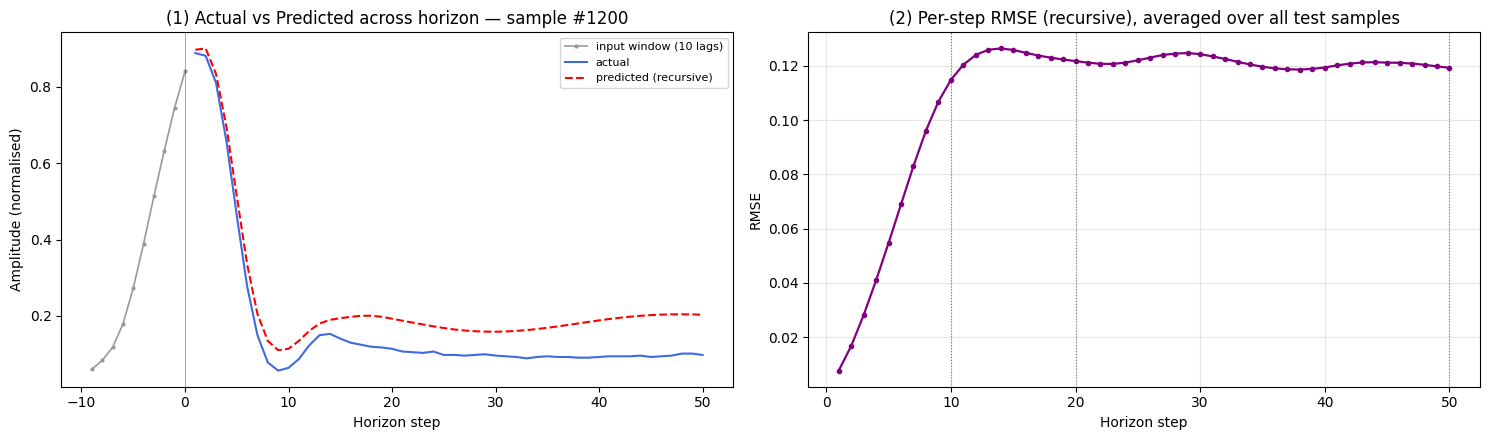

Saved: multistep_103.png


In [ ]:
import time

assert HORIZON == 1, "recursive rollout assumes a 1-step base model (config HORIZON must be 1)"

EVAL_HORIZONS = [10, 20, 50]          
HMAX          = max(EVAL_HORIZONS)
CLIP          = (-0.5, 1.5)          
d = patient_data[DEMO_PATIENT]        

def recursive_forecast(model, X0, H, clip=CLIP):
    """Roll the 1-step model out H steps: predict -> clip -> append as newest lag -> repeat."""
    win = X0.copy(); out = np.empty((len(X0), H), np.float32); lo, hi = clip
    for h in range(H):
        p = np.clip(model.predict(win), lo, hi).astype(np.float32)
        out[:, h] = p
        win = np.concatenate([win[:, 1:], p[:, None]], axis=1)   
    return out


future = lambda y, H: y[np.arange(len(y) - H + 1)[:, None] + np.arange(H)[None, :]]   # (n, H)

val_true = future(d['y_val'], HMAX)
sub      = np.random.RandomState(SEED).choice(len(val_true), size=min(1500, len(val_true)), replace=False)
X0v, Tv  = d['X_val'][sub], val_true[sub]

def objective(trial):
    alpha  = trial.suggest_float('alpha', 1e-8, 1e0, log=True)
    degree = trial.suggest_int('degree', 2, 3)
    m = build(alpha, degree).fit(d['X_train'], d['y_train'])     
    return rmse(recursive_forecast(m, X0v, HMAX), Tv)            

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=15, show_progress_bar=False)
best  = study.best_params
model = build(**best).fit(d['X_train'], d['y_train'])
print(f'Recursive NG-RC / NVAR — patient {DEMO_PATIENT} | best params (multi-step val): {best}')


rows = []
for H in EVAL_HORIZONS:
    T   = future(d['y_test'], H)
    t0  = time.perf_counter()
    P   = recursive_forecast(model, d['X_test'][:len(T)], H)      
    sec = time.perf_counter() - t0
    r2  = 1 - np.sum((T - P) ** 2) / np.sum((T - T.mean()) ** 2)  
    rows.append({
        'Horizon'        : H,
        'RMSE'           : round(rmse(P, T), 6),
        'MAE'            : round(float(np.mean(np.abs(P - T))), 6),
        'R Squared'      : round(float(r2), 5),
        'Comp. time (s)' : round(sec, 3),
    })
metrics = pd.DataFrame(rows).set_index('Horizon')
print('\nSection 3 — computed metrics (recursive, over all test samples):')
display(metrics)

Tfull = future(d['y_test'], HMAX)
Pfull = recursive_forecast(model, d['X_test'][:len(Tfull)], HMAX)
per_step = np.sqrt(((Pfull - Tfull) ** 2).mean(axis=0))      # RMSE at each horizon step

idx = 1200   # representative test sample 
fig, ax = plt.subplots(1, 2, figsize=(15, 4.5))
ax[0].plot(range(1 - LOOKBACK, 1), d['X_test'][idx], color='0.6',       lw=1.2, marker='o', ms=2, label=f'input window ({LOOKBACK} lags)')
ax[0].plot(range(1, HMAX + 1),     Tfull[idx],       color='royalblue', lw=1.5, label='actual')
ax[0].plot(range(1, HMAX + 1),     Pfull[idx],       color='red',       lw=1.5, ls='--', label='predicted (recursive)')
ax[0].axvline(0, color='k', lw=0.6, alpha=0.4)
ax[0].set_title(f'(1) Actual vs Predicted across horizon — sample #{idx}')
ax[0].set_xlabel('Horizon step'); ax[0].set_ylabel('Amplitude (normalised)'); ax[0].legend(fontsize=8)

ax[1].plot(range(1, HMAX + 1), per_step, color='purple', lw=1.6, marker='o', ms=3)
for H in EVAL_HORIZONS:
    ax[1].axvline(H, color='k', ls=':', lw=0.8, alpha=0.5)
ax[1].set_title('(2) Per-step RMSE (recursive), averaged over all test samples')
ax[1].set_xlabel('Horizon step'); ax[1].set_ylabel('RMSE'); ax[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('multistep_103.png', dpi=140, bbox_inches='tight')
plt.show()
print('Saved: multistep_103.png')